### Corrective-RAG:
Corrective RAG (CRAG) is an advanced technique within Retrieval-Augmented Generation (RAG) that focuses on improving the accuracy and relevance of generated responses by incorporating mechanisms for self-reflection and self-grading of retrieved documents. It does this by evaluating the quality of retrieved documents and applying corrective actions when necessary, such as refining or replacing incorrect retrievals

Note: In this tutorial, the corrective actions are re-writing the query and Web-Sesrch but it may vary for different systems and use cases

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

In [4]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS

c:\Users\bhanu\Desktop\AI Agents course\AI-Agents-Learning\AgenticAIWorkspace\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [6]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [23]:
from typing import Annotated, Sequence,List
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage,HumanMessage,AIMessage,SystemMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate,ChatPromptTemplate
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from typing_extensions import Literal
from pydantic import BaseModel,Field
from langchain_classic import hub as prompts
from langsmith import Client
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_core.tools import create_retriever_tool
from langchain_core.documents import Document
from langchain_community.tools.tavily_search import TavilySearchResults

In [8]:
urls=[
"https://docs.langchain.com/oss/python/langgraph/overview/",
"https://docs.langchain.com/oss/python/langgraph/workflows-agents/",
"https://docs.langchain.com/oss/python/langgraph/graph-api#map-reduce-and-the-send-api"
]
docs=[WebBaseLoader(url).load() for url in urls]
doc_list=[doc for sublist in docs for doc in sublist]
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
doc_splits=text_splitter.split_documents(doc_list)
vectorstore=FAISS.from_documents(documents=doc_splits,embedding=HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2"))

retriever=vectorstore.as_retriever()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2430.71it/s]


In [13]:
### Retrieval grader
class GradeDocuments(BaseModel):
    """Binary score for relevant check on retrieved documents."""

    binary_score:str=Field(description="Documents are relevant to the question, 'yes' or 'no'")

In [14]:
llm=ChatGroq(model="openai/gpt-oss-20b")
structured_llm_grader=llm.with_structured_output(GradeDocuments)

system="""You are a grader assessing relevance of a retrieved document to a user question. \n
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.
    """

grade_prompt=ChatPromptTemplate.from_messages(
    [
        ("system",system),
        ("human","Retrieved document: \n\n {document} \n\n User question: {question}")
    ]
)

retrieval_grader=grade_prompt | structured_llm_grader
question="What are the main components of LangGraph?"
docs=retriever.invoke(question)
docs_txt=docs[1].page_content
print(retrieval_grader.invoke({"question":question,"document":docs_txt}))

binary_score='yes'


In [15]:
from langsmith import Client
client = Client()

In [17]:
#Prompt
prompt=client.pull_prompt("rlm/rag-prompt",dangerously_pull_public_prompt=True)

In [ ]:
#Post processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [20]:
#Chain
rag_chain=prompt | llm | StrOutputParser()

In [21]:
generation=rag_chain.invoke({"context":docs,"question":question})
print(generation)

LangGraph models agent workflows as directed graphs, letting you build agents by wiring together three core pieces.  
These pieces are the **graph** itself, the **nodes** (functions or sub‑tasks that run), and the **edges** (the connections that dictate control flow and data passing).  
Together they provide the low‑level plumbing for durable, streaming, and human‑in‑the‑loop agent execution.


In [22]:
### Question rewriter

system="""You are a question re-writer that converts an input question to a better version that is optimized \n
    for web search. Look at the input and try to reason about the underlying semantic intent / meaning"""

re_write_prompt=ChatPromptTemplate.from_messages(
    [
        ("system",system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question."
        )
    ]
)

question_rewriter=re_write_prompt | llm | StrOutputParser()
question_rewriter.invoke({"question":question})

'What are the primary components that comprise the LangGraph framework?'

In [24]:
web_search_tool=TavilySearchResults(k=3)

C:\Users\bhanu\AppData\Local\Temp\ipykernel_6612\2495305207.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool=TavilySearchResults(k=3)


In [25]:
class GraphState(TypedDict):
    question:str
    generation:str
    web_search:str
    documents:List[str]

In [27]:
def retrieve(state):
    """Retrieve documents
    
    Args:
        state (dict): New key added to state, documents, that contains retrieved documents    
    """
    print("---RETRIEVE---")
    question=state["question"]

    #Retrieval
    documents=retriever.invoke(question)
    return {"documents":documents, "question":question}

def generate(state):
    """
    Generate answer
    
    Args:
       state (dict): The curent graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """

    print("--GENERATE---")
    question=state["question"]
    documents=state["documents"]

    #RAG generation
    generation = rag_chain.invoke({"context":documents,"question":question})
    return {"documents":documents,"question":question,"generation":generation}

def grade_documents(state):
    """
    Determine whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state
    
    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """
    print("---CHECK DOCUMENT RELAVANCE TO QUESTION---")
    question=state["question"]
    documents=state["documents"]

    #Score each doc
    filtered_docs=[]
    web_search="No"
    for d in documents:
        score = retrieval_grader.invoke(
            {"question":question,"document":d.page_content}
        )
        grade=score.binary_score
        if grade=="yes":
            print("--GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEAVANT---")
            web_search="Yes"
            continue
    return {"documents":filtered_docs,"question":question,"web_search":web_search}

def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
       state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question=state["question"]
    documents=state["documents"]

    #Re-write question
    better_question=question_rewriter.invoke({"question":question})
    return {"documents":documents,"question":better_question}

def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state    
    
    Returns:
        state (dict): Updates documents key with appended web results    
    """
    print("---WEB SEARCH---")
    question=state["question"]
    documents=state["documents"]

    #Web search
    docs=web_search_tool.invoke({"query":question})
    web_results="\n".join([d["content"] for d in docs])
    web_results=Document(page_content=web_results)

    return {"documents":documents, "question":question}

def decide_to_generate(state):
    """
    Determine whether to generate an answer, or re-generate a question.
    
    Args:
        state(dict): The current graph state
    
    Returns:
        str: Binary decision for next node to call
    """

    print("--ASSESS GRADED DOCUMENTS---")
    state["question"]
    web_search=state["web_search"]
    state["documents"]

    if web_search=="Yes":
        print("---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---")
        return "transform_query"
    else:
        print("---DECISION: GENERATE---")
        return "generate"

In [28]:
workflow=StateGraph(GraphState)

workflow.add_node("retrieve",retrieve)
workflow.add_node("grade_documents",grade_documents)
workflow.add_node("transform_query",transform_query)
workflow.add_node("web_search_node",web_search)
workflow.add_node("generate",generate)

workflow.add_edge(START,"retrieve")
workflow.add_edge("retrieve","grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query":"transform_query",
        "generate":"generate"
    }
)
workflow.add_edge("transform_query","web_search_node")
workflow.add_edge("web_search_node","generate")
workflow.add_edge("generate",END)

app=workflow.compile()

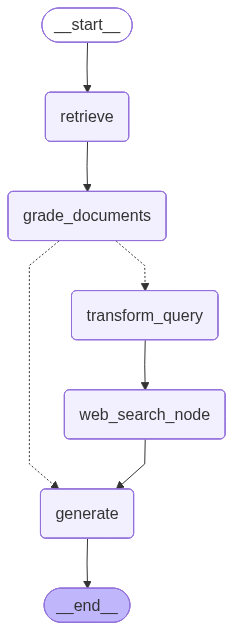

In [30]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [31]:
app.invoke({"question":"What is LangGraph and its main components?"})

---RETRIEVE---
---CHECK DOCUMENT RELAVANCE TO QUESTION---
--GRADE: DOCUMENT RELEVANT---
--GRADE: DOCUMENT RELEVANT---
--GRADE: DOCUMENT RELEVANT---
--GRADE: DOCUMENT RELEVANT---
--ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE---
--GENERATE---


{'question': 'What is LangGraph and its main components?',
 'generation': 'LangGraph is a low‑level Python framework that models agent workflows as directed graphs, giving fine‑grained control over execution.  \nIts core components are the **graph definition** (nodes and edges that describe the workflow), the **state** that carries data and context between nodes, and the **runtime** that executes the graph with durability, streaming, and human‑in‑the‑loop support.  \nTogether these elements provide durable, fault‑tolerant orchestration for complex agent tasks.',
 'web_search': 'No',
 'documents': [Document(id='ca557e63-0630-4e97-8595-3b143cde8469', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/graph-api#map-reduce-and-the-send-api', 'title': 'Graph API overview - Docs by LangChain', 'language': 'en'}, page_content='At its core, LangGraph models agent workflows as graphs. You define the behavior of your agents using three key components:'),
  Document(id='eec51b45

In [32]:
app.invoke({"question":"What is Machine Learning?"})

---RETRIEVE---
---CHECK DOCUMENT RELAVANCE TO QUESTION---
---GRADE: DOCUMENT NOT RELEAVANT---
---GRADE: DOCUMENT NOT RELEAVANT---
---GRADE: DOCUMENT NOT RELEAVANT---
---GRADE: DOCUMENT NOT RELEAVANT---
--ASSESS GRADED DOCUMENTS---
---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---
---TRANSFORM QUERY---
---WEB SEARCH---
--GENERATE---


{'question': '**Improved question for web search**\n\n"What is machine learning? A concise definition and real‑world examples"',
 'generation': 'Machine learning is a branch of artificial intelligence that trains algorithms to learn patterns from data and improve performance without explicit programming. It typically involves statistical models that adjust their parameters based on input‑output examples to make predictions or decisions. Real‑world examples include spam email filtering, movie recommendation engines, autonomous vehicle navigation, and medical image diagnostics.',
 'web_search': 'Yes',
 'documents': []}